# Apple VS Banana
- apple width = 6
- apple height = 6
- banana width = 4
- banana height = 8

apple = 0

banana = 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.src.metrics.metrics_utils import confusion_matrix
from matplotlib.colors import ListedColormap

In [3]:
def generate_dataset(n):
    apple_width = np.random.normal(6,1,n)
    apple_height = np.random.normal(6,1,n)
    banana_width = np.random.normal(4,1,n)
    banana_height = np.random.normal(8,1,n)
    width = np.concatenate((apple_width, banana_width))
    length = np.concatenate((apple_height, banana_height))
    X = np.array([width, length]).T
    Y_apples = np.zeros(n, dtype=int)
    Y_banana = np.ones(n, dtype=int)
    Y = np.concatenate((Y_apples, Y_banana))
    return X, Y

In [4]:
X_train,Y_train = generate_dataset(100)

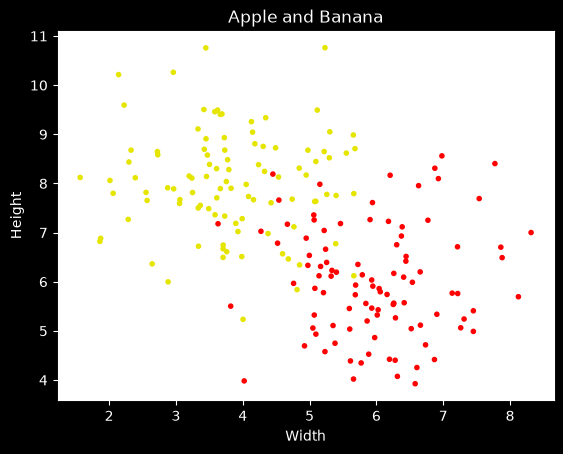

In [5]:
ax = plt.gca()
ax.set_facecolor('white')
cmap = ['red','#E5E500']
plt.scatter(X_train[:,0],X_train[:,1],c=Y_train,
            cmap=ListedColormap(cmap),marker='.')
plt.title('Apple and Banana')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()

In [6]:
class KNN:
    def __init__(self,k):
        self.Y_train = None
        self.X_train = None
        self.k = k

    def euclidean_distance(self,x1, x2):
        return np.sqrt(np.sum((x1-x2) ** 2))

    #Training
    def fit(self,X,Y):
        self.X_train = X
        self.Y_train = Y

    #Predict
    def predict(self,X):
        Y = []
        for x in X:
            distances = []
            for x_train in self.X_train:
                distances.append(self.euclidean_distance(x,x_train))
            nearest_neighbour = np.argsort(distances)[0:self.k]
            y = np.argmax(np.bincount(Y_train[nearest_neighbour]))
            Y.append(y)
        return Y

    def evaluate(self,X,Y):
        Y_predict = self.predict(X)
        accuracy = np.sum(Y_predict == Y)/len(Y)
        return accuracy


In [7]:
knn = KNN(k=5)
knn.fit(X_train,Y_train)
new_fruit = np.array([2,8])
new_fruit2 = np.array([2,4])
new_fruit3 = np.array([6,6])
new_fruit4 = np.array([4,10])
new_fruit5 = np.array([5,8])
new_fruit6 = np.array([3,3])
new_fruit7 = np.array([3,10])
new_fruit8 = np.array([7,7])
new_fruit9 = np.array([7,9])
new_fruit10 = np.array([3,12])
new_fruit11 = np.array([10,20])
new_fruits = [new_fruit,new_fruit2,new_fruit3,new_fruit4,
              new_fruit5,new_fruit6,new_fruit7,new_fruit8,
              new_fruit9,new_fruit10,new_fruit11]
result = knn.predict(new_fruits)
for r in result:
    if r == 0:
        print("🍎",end=" ")
    elif r == 1:
        print("🍌",end=" ")

🍌 🍌 🍎 🍌 🍌 🍎 🍌 🍎 🍎 🍌 🍌 

In [8]:
X_test,Y_test = generate_dataset(90)

In [9]:
knn.evaluate(X_test,Y_test)

np.float64(0.9)

In [10]:
y_pred = knn.predict(X_test)

In [11]:
confusion_matrix = np.zeros((2,2))
for i in range(len(y_pred)):
    if Y_test[i] == 0 and y_pred[i] == 0:
        confusion_matrix[0][0] += 1
    elif Y_test[i] == 0 and y_pred[i] == 1:
        confusion_matrix[0][1] += 1
    elif Y_test[i] == 1 and y_pred[i] == 0:
        confusion_matrix[1][0] += 1
    elif Y_test[i] == 1 and y_pred[i] == 1:
        confusion_matrix[1][1] += 1

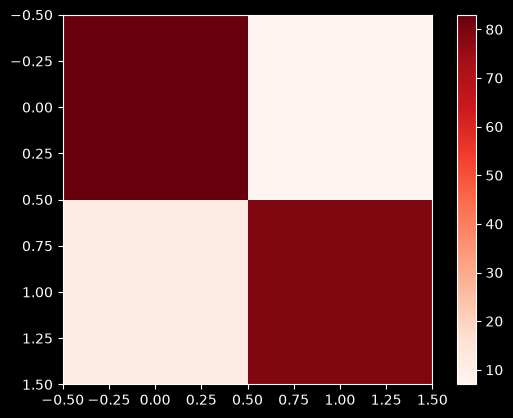

In [17]:
plt.imshow(confusion_matrix, cmap="Reds")
plt.colorbar()
plt.show()

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train,Y_train)
new_fruit = np.array([2,8])
new_fruit2 = np.array([2,4])
new_fruit3 = np.array([6,6])
new_fruit = np.array([2,8])
new_fruit2 = np.array([2,4])
new_fruit3 = np.array([6,6])
new_fruit4 = np.array([4,10])
new_fruit5 = np.array([5,8])
new_fruit6 = np.array([3,3])
new_fruit7 = np.array([3,10])
new_fruit8 = np.array([7,7])
new_fruit9 = np.array([7,9])
new_fruit10 = np.array([3,12])
new_fruit11 = np.array([10,20])
new_fruits = [new_fruit,new_fruit2,new_fruit3,new_fruit4,
              new_fruit5,new_fruit6,new_fruit7,new_fruit8,
              new_fruit9,new_fruit10,new_fruit11]
outputs = knn2.predict(new_fruits)
for output in outputs:
    if output == 0:
        print("🍎",end=" ")
    elif output == 1:
        print("🍌",end=" ")

🍌 🍌 🍎 🍌 🍌 🍎 🍌 🍎 🍎 🍌 🍌 

In [19]:
knn2.score(X_test,Y_test)

0.9

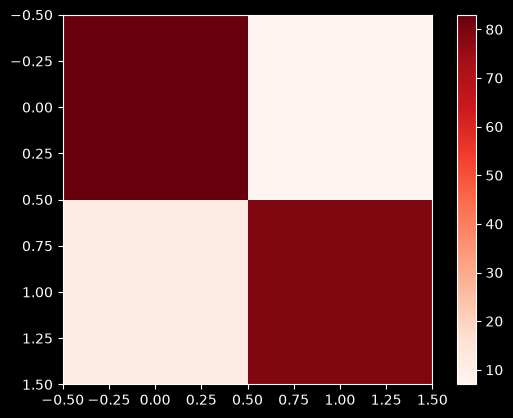

In [20]:
from sklearn.metrics import confusion_matrix
Y_predict = knn.predict(X_test)
cm = confusion_matrix(Y_test,Y_predict)
plt.imshow(cm, cmap="Reds")
plt.colorbar()
plt.show()